### Housing data (regression), dataset evaluation report

Target variable is **price** (continuous, regression).

Price range is 75 000 - 7 700 000 USD, some outliers in the high-end.

<hr>

**Variables to drop or to process further**

- **id** can be dropped (no significance in this context, just an identifier field)
- **date** only contains one year of time, if used, needs to be processed by years/months/quarters etc. Since it's only one year of time, can also be dropped.
- **lat, long, zipcode** have be to considered separately, since they are spatial meta information => location of the house
    - location plays a crucial role in house market, but we have to use proper methods in order to use these variables (clustering, distance to city centre etc.)
    - using lat/long as they are is dangerous, because they look like conventional measurements to a ML model, but they are actually coordinates

**Rest of the variables**

- bedrooms
- bathrooms
- sqft_living
- sqft_lot
- floors
- waterfront
- view
- condition
- grade
- sqft_above
- sqft_basement
- yr_built
- yr_renovated
- sqft_lot15

<hr>

**Variable importance and redundancy analysis**

**price** is highly correlated with **grade, sqft_living, sqft_living15 and sqft_above**. (Source: y-data-report). 

**bathrooms** also seem to have a connection to **price**, where as **view** and **floors** seem to have a milder connection.

There might be redundancy in the sqft_columns. For example, **sqft_living = sqft_above + sqft_basement**. This means we have derived variables regarding square footage, containing possibly a considertable amount of redundancy.

**VIF-test for multicollinearity**

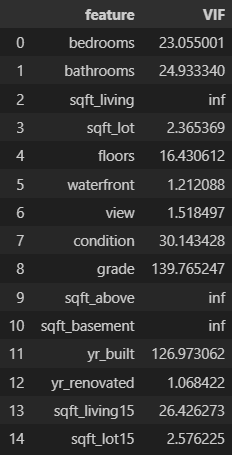

We can see in the VIF-test: **sqft_living, sqft_above and sqft_basement** have positive infinite VIF-test score, implying extreme multicollinearity and redundancy. Few options we can try with these variables:

- Option 1: remove sqft_living and preserve sqft_above and sqft_basement
- Option 2: change sqft_basement to boolean category: (has basement, no basement - 1/0), and remove one of the other variables

<hr>

**Data imbalances**

Variables **waterfront** amd **view** are extremely imbalanced (one-sided). 

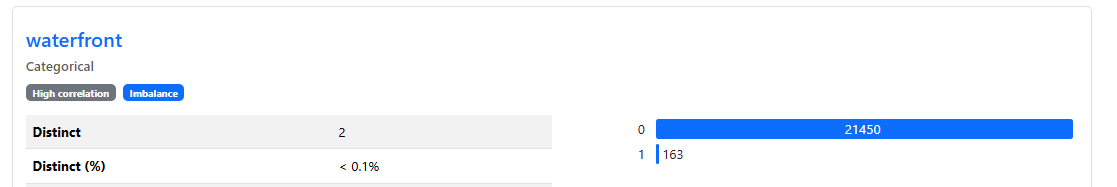

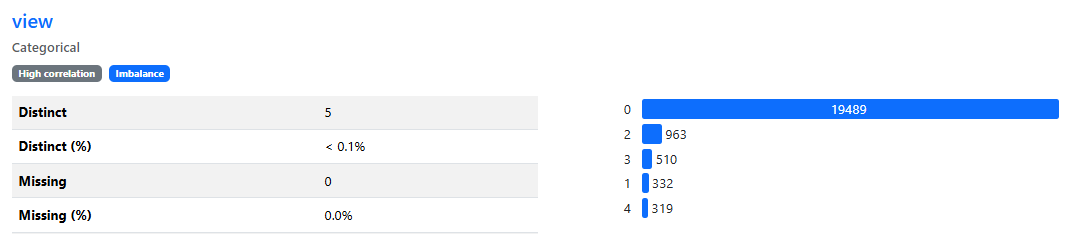

Things to consider for waterfront/view: 

- Approach 1: Under-/oversampling techniques + synthesize more data (CTGAN, CopulaSynthesizer etc)
    - However, the imbalance is so extreme, we might need to consider other options
- Approach 2: We could combine waterfront and view into a single variable, but then again, distributions are so imbalanced, they are almost like outliers (most houses have a bad view), or maybe convert these variables into boolean variables

**sqft_basement and yr_renovated**

**yr_renovated** has a high number of zeroes (~96%). Ideas to try in future:
- combine yr_built and yr_renovated => yr_built_or_last_renovation. The idea is to have the latest year in one column when any kind of construction work was done in this house.

**sqft_basement** has over 60% zero values, indicates many of the houses don't have a basement. Ideas to try:

- convert sqft_basement into a categorical binned variable -> no basement, small basement, average basement, large basement
    - however, boolean variable (no basement/has basement) is probably the best conversion, due to majority of houses not having a basement

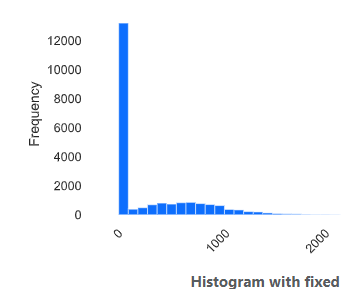

If using **yr_built** either directly or combined with **yr_renovated** => there's a small balance issue in the ataset => more newer than older buildings in the dataset. This is probably natural, since older houses often have to be demolished.

There's also a small gap in 1929 onwards => probably The Great Depression. (due to economy reasons, only few buildings were made.)

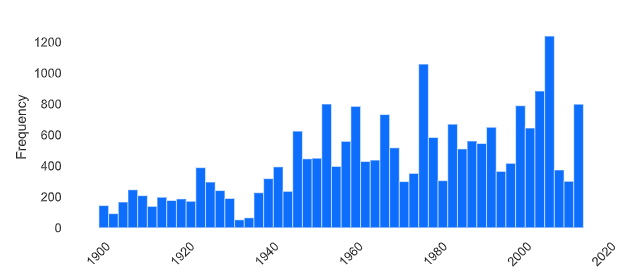

TODO: add floors-variable and ideas on how to combine different values

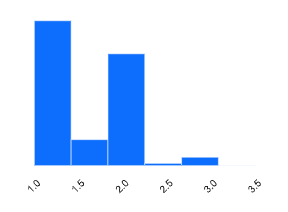

___

**Distributions**

Target variable (price) distribution. Not quite normal distribution, some outliers in the high end. Since this is the target variable of a regression problem, we should aim to optimize (normalize, outlier removal, sampling techniques etc.) this distribution to be close to normal distribution to maximize machine learning model performance.

However, we have to be careful not to over-optimize, so that our model still works with real data as well.

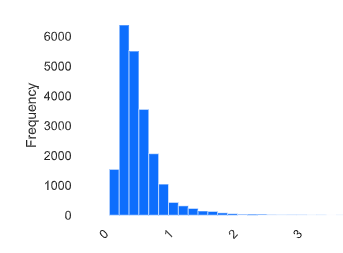

Another idea for optimization - transformation algorithms, for examples (just ideas, asked from ChatGPT):
- Log transformation
- Box-Cox transformation
- Yeo-Johnson transformation
- Quantile transformation
- etc. 

**Support variable distributions**

Support variables are usually not as sensitive on being a normal distribution (or uniform distribution in some cases). As long as the variable has good predictive power (see SHAP/LIME etc.), the distribution can be good. However, if the predictive power is not good, consider optimizing support variable distributions as well.

bathrooms have a sporadic distribution, which is partially due to the system used in US (e.g. 2.5 bathrooms means => 2 full bathrooms (including a shower/bathtub) and 1 bathroom with only toilet and sink (0.5 bathrooms). This variable is probably good to keep in mind, whether we need to simplify the data structure for an easier distribution. 

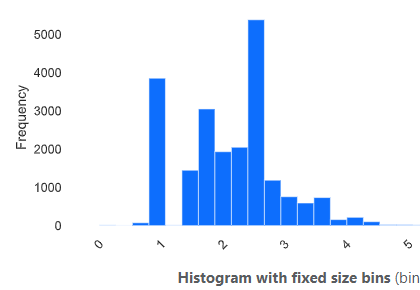

Explanation on the US bathroom amount system:

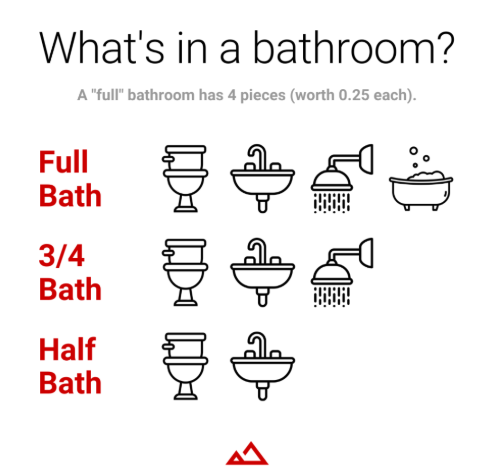

Source: https://danmccurley.com/wp-content/uploads/bathroom-infographic-1024x1024.png

**Based on the picture above**, it might be a good idea to keep the variable as it is for now, since the numeric values (decimals) hide quite a lot of details in them.

bedrooms are quite heavily concentrated, most values being 2-5 bedrooms. This variable probably needs simplifaction and/or outlier removal. Probably good to check this balance again after the outliers in target variable have been removed.

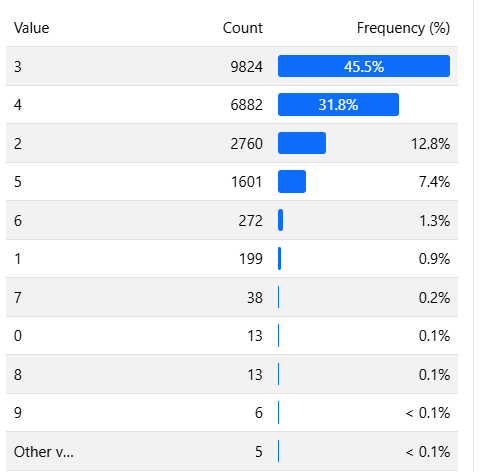

sqft_living is almost normal distribution, only slightly skewed and small amoutn of potential outliers in the high-end. We can probably fix this with sampling techniques or outlier removal later. We can also probably assume most of the larger buildings belong to the most expensive buildings => "fix the price distribution => we also fix this distribution"

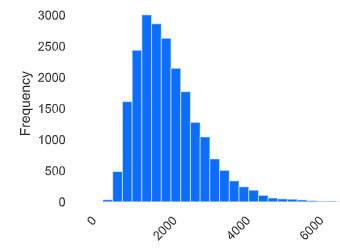

TODO: compare price vs square foot living distribution (seaborn) to justify if bigger houses are the most expensive ones

TODO: discuss the grade-variable distribution below

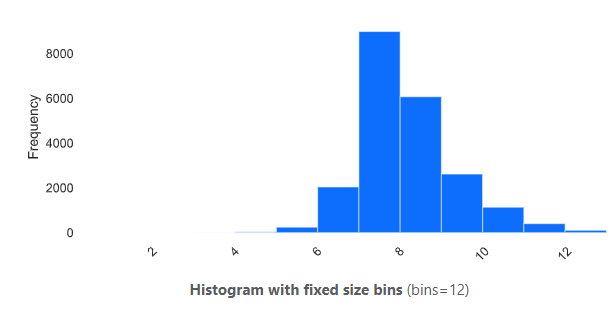

___

**Overall trends and irregularities**

___

TODO: inspect and discuss overlap between variables

NOTE: SHAP and LIME both belong to the domain of Explainable AI

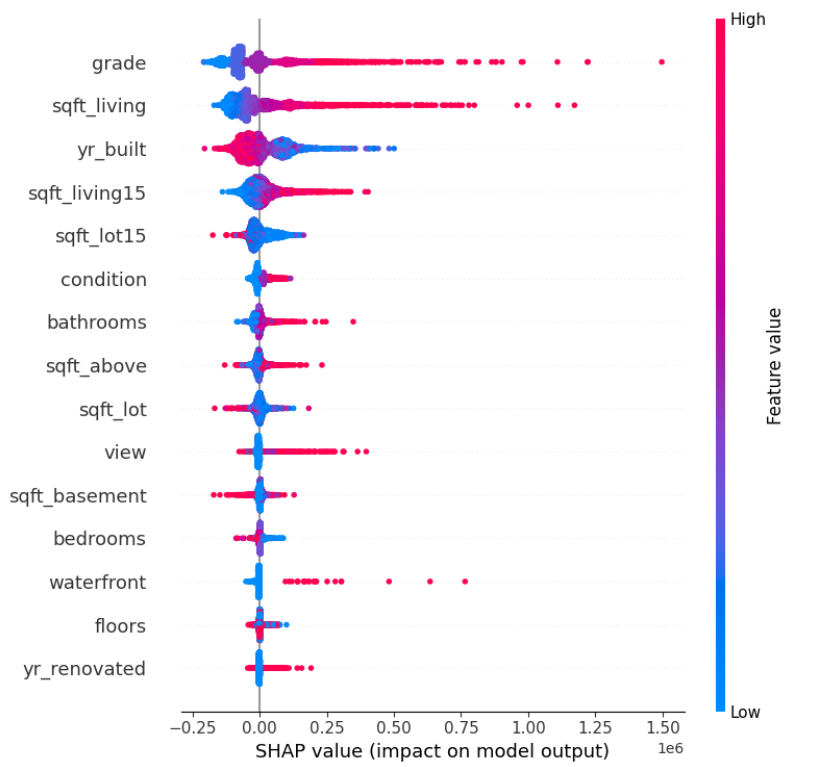

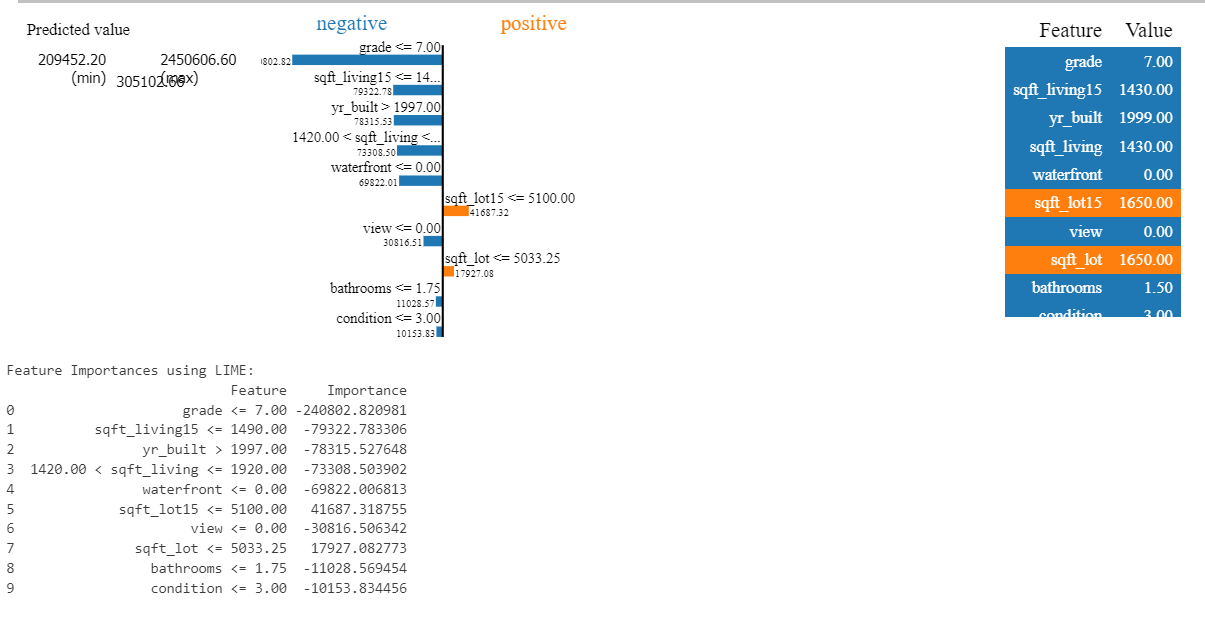

TODO: explain SHAP and LIME results, compare to each other

TODO: DISCUSS OVERLAPPING IN VARIABLES (it seems the housing dataset does not really have an issue with overlapping, it's more of a problem in the red wine dataset)

### Summary of key points:

In [ ]:
# TODO: study redundancy with VIF-test (multicollinearity)